In [4]:
import xarray as xr
from matplotlib import pyplot as plt

from leakage.conversions import dop2vel
from sca_module.dopsca_setup import DopSCAConfig

plt.rcParams.update({'font.size': 10, 'font.weight' : 'bold'})

### 0 - Parameters

In [5]:
sca = DopSCAConfig()
sca.Lambda = sca.get_wavelength()
sca.grid_spacing_target = sca.get_grid_spacing_target(magic_divider=2)

### 1 - Load LUTs

In [8]:
lut_dop = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/dop_lut_20250213_companion350km.nc')['dop_S1_V']
lut_nrcs = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/nrcs_lut_20250213_companion350km.nc')['nrcs_S1_V'] # <-- not used here

lut_vel = dop2vel(
    Doppler=lut_dop,
    Lambda=sca.Lambda,
    angle_azimuth=90,
    angle_incidence=lut_dop.incidence.to_numpy()[None, None, :, None]
)

### 2 - Assess inverse-wave-age-induced velocity spread

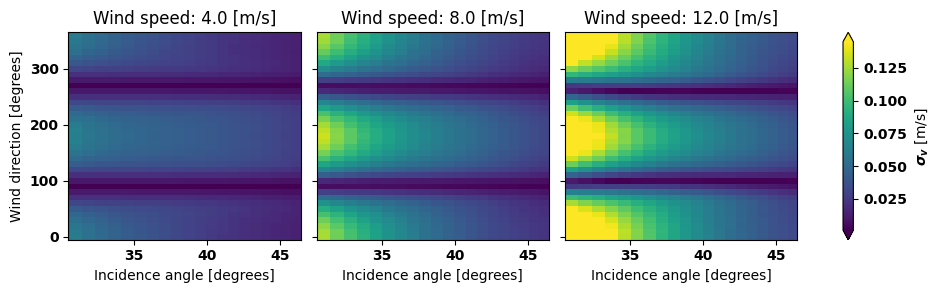

In [16]:
fig = lut_vel.sel(wind_norm = slice(4, 12, 8)).std(dim='wave_age').plot(col='wind_norm', robust = True, cbar_kwargs={"label": r"$\sigma_v$ [m/s]"},)
for i, ax in enumerate(fig.axs.flat):
    ax.set_xlabel("Incidence angle [degrees]")
    ax.set_title(f"Wind speed: {(1+i)*4:.1f} [m/s]")

_ = fig.axs.flat[0].set_ylabel("Wind direction [degrees]")